In [31]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import random
import cv2
from tensorflow.keras.preprocessing import image

In [32]:
# Thiết lập các tham số
IMG_SIZE = 224 
BATCH_SIZE = 32
EPOCHS = 50

train_path = "../Data_Final/train"
val_path   = "../Data_Final/val"
test_path  = "../Data_Final/test"

In [33]:
# Kiểm tra GPU
print("GPU khả dụng: ", tf.config.list_physical_devices('GPU'))
print("Phiên bản TensorFlow:", tf.__version__)

GPU khả dụng:  []
Phiên bản TensorFlow: 2.20.0


In [34]:
# Tăng cường dữ liệu cho tập train
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    # Giảm bias hình dạng / kích thước
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    # Giảm bias màu sắc
    brightness_range=[0.7, 1.3],
    channel_shift_range=30.0
)

# Chỉ rescale cho tập validation và test
val_gen = ImageDataGenerator()
test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

# Nạp dữ liệu
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_data.class_indices.keys())

print(f"\nSố lượng lớp: {train_data.num_classes}")
print(f"Nhãn các lớp: {train_data.class_indices}")

Found 1966 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Found 424 images belonging to 2 classes.

Số lượng lớp: 2
Nhãn các lớp: {'fresh': 0, 'rotten': 1}


In [35]:
# Tải mô hình EfficientNetB0 đã được huấn luyện trước
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print(f"Mô hình cơ sở có {len(base_model.layers)} layers")

Mô hình cơ sở có 238 layers


In [36]:
# Giai đoạn 1: Đóng băng các layer, chỉ huấn luyện 30 layer cuối
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Kiểm tra số lượng layer có thể huấn luyện
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Số layer có thể huấn luyện: {trainable_count}/{len(base_model.layers)}")

Số layer có thể huấn luyện: 30/238


In [37]:
# Xây dựng mô hình
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    train_data.num_classes,
    activation="softmax"
)(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,383,141 (16.72 MB)

 Trainable params: 1,827,170 (6.97 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

In [38]:
# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Mô hình đã được biên dịch thành công!")

Mô hình đã được biên dịch thành công!


In [39]:
# Thiết lập các callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Tạo thư mục để lưu mô hình
os.makedirs("../models", exist_ok=True)

checkpoint = ModelCheckpoint(
    "../models/efficientnetb0_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

print("Đã cấu hình callbacks")

Đã cấu hình callbacks


In [40]:
# Train giai đoạn 1
start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Giai đoạn 2: Fine - Tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time()
print(f"Tổng thời gian huấn luyện: {end_time - start_time:.2f} giây")

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6718 - loss: 0.8184
Epoch 1: val_accuracy improved from None to 0.92381, saving model to ../models/efficientnetb0_best.keras

Epoch 1: finished saving model to ../models/efficientnetb0_best.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8082 - loss: 0.4689 - val_accuracy: 0.9238 - val_loss: 0.2355 - learning_rate: 1.0000e-04
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9384 - loss: 0.1595
Epoch 2: val_accuracy improved from 0.92381 to 0.98333, saving model to ../models/efficientnetb0_best.keras

Epoch 2: finished saving model to ../models/efficientnetb0_best.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9400 - loss: 0.1506 - val_accuracy: 0.9833 - val_loss: 0.0958 - learning_rate: 1.0000e-04
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9666 - loss: 0.0944
Epoch 3: val_accuracy did not improve from 0.98333
62/62 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9700 

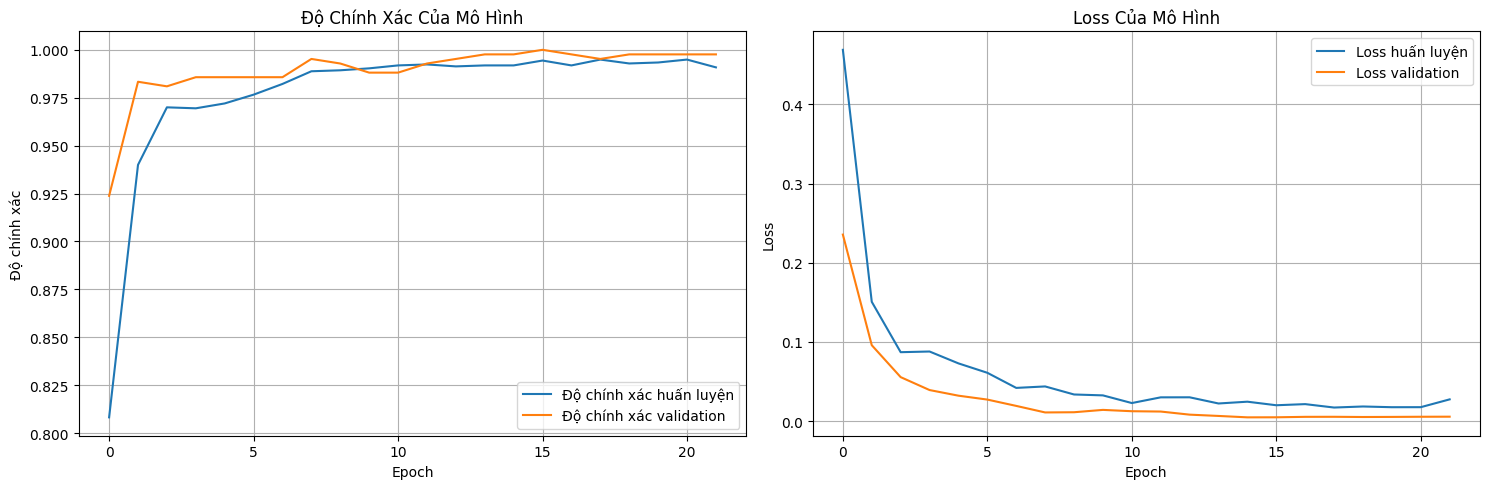

In [41]:
# Biểu đồ quá trình huấn luyện
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Vẽ biểu đồ độ chính xác
ax1.plot(history.history['accuracy'], label='Độ chính xác huấn luyện')
ax1.plot(history.history['val_accuracy'], label='Độ chính xác validation')
ax1.set_title('Độ Chính Xác Của Mô Hình')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Độ chính xác')
ax1.legend()
ax1.grid(True)

# Vẽ biểu đồ loss
ax2.plot(history.history['loss'], label='Loss huấn luyện')
ax2.plot(history.history['val_loss'], label='Loss validation')
ax2.set_title('Loss Của Mô Hình')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [42]:
# Đánh giá trên tập test
test_loss, test_accuracy = model.evaluate(test_data, verbose=1)

print(f"\nLoss trên tập test: {test_loss:.4f}")
print(f"Độ chính xác trên tập test: {test_accuracy:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 891ms/step - accuracy: 0.9976 - loss: 0.0039

Loss trên tập test: 0.0039
Độ chính xác trên tập test: 0.9976


In [43]:
# Dự đoán
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 989ms/step

Classification Report:

              precision    recall  f1-score   support

       fresh       1.00      0.99      1.00       195
      rotten       1.00      1.00      1.00       229

    accuracy                           1.00       424
   macro avg       1.00      1.00      1.00       424
weighted avg       1.00      1.00      1.00       424



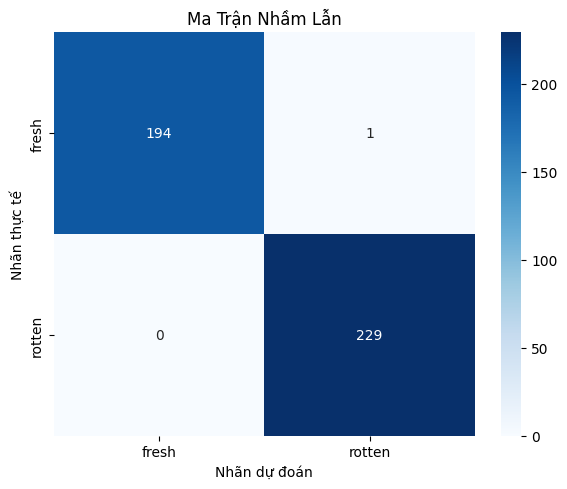


Độ Chính Xác Từng Lớp:
fresh: 99.49%
rotten: 100.00%


In [44]:
# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Ma Trận Nhầm Lẫn')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()
plt.show()

# In độ chính xác cho từng lớp
print("\nĐộ Chính Xác Từng Lớp:")
for i, class_name in enumerate(class_names):
    class_accuracy = cm[i, i] / cm[i].sum() * 100
    print(f"{class_name}: {class_accuracy:.2f}%")

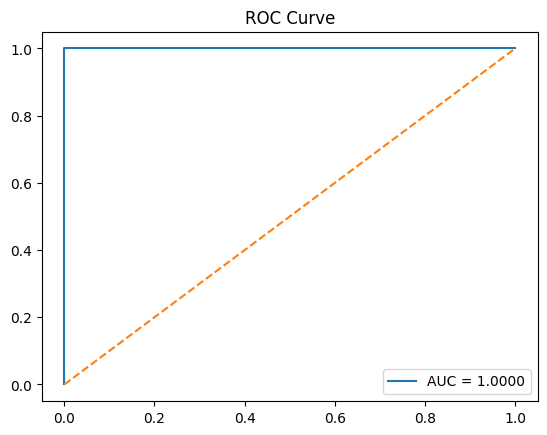

In [45]:
# ROC CURVE (2 lớp)
if len(class_names) == 2:
    fpr, tpr, _ = roc_curve(true_classes, predictions[:,1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()


Số ảnh dự đoán sai: 1


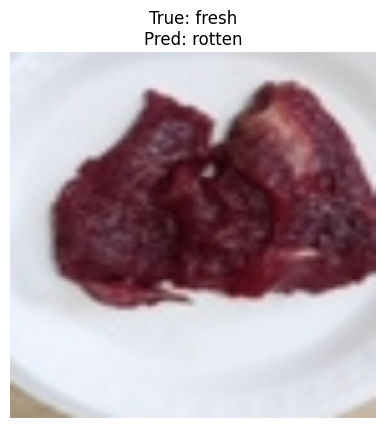

In [46]:
# ERROR ANALYSIS
misclassified = np.where(predicted_classes != true_classes)[0]
print(f"\nSố ảnh dự đoán sai: {len(misclassified)}")

plt.figure(figsize=(12,12))
for i, idx in enumerate(misclassified[:6]):
    img_path = test_data.filepaths[idx]
    img = plt.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {class_names[true_classes[idx]]}\nPred: {class_names[predicted_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

d:\App\python\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_745']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


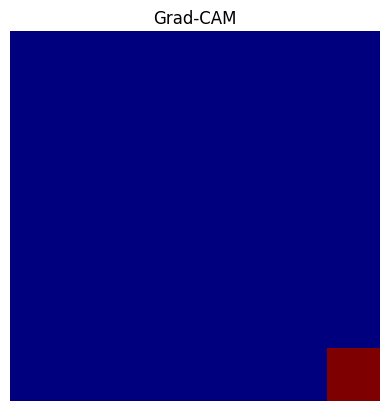

In [47]:
# GRAD-CAM
last_conv_layer_name = "top_conv"

grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer_name).output, model.output]
)

def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

if len(misclassified) > 0:
    idx = misclassified[0]
    img_path = test_data.filepaths[idx]
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    heatmap = make_gradcam_heatmap(img_array)

    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis("off")
    plt.show()

In [48]:
# Lưu mô hình cuối cùng
model.save('../models/efficientnetb0_final.keras')
model.save('../models/efficientnetb0_final.h5')

print("\nĐã lưu mô hình thành công!")


Đã lưu mô hình thành công!
